In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
import unicodedata
df = pd.read_csv("US-National-Parks_Use_1979-2023_By-Month.csv")
loc_df = pd.read_csv("df_2.csv")
# df.head()
#loc_df.head()

In [21]:
#Clean park names for matching
def clean_park_name(name):
    # normalize unicode characters (fixes Haleakalā, Hawaiʻi, etc.)
    name = unicodedata.normalize('NFKD', name)
    name = name.encode('ascii', 'ignore').decode('utf-8')

    name = name.lower()
    
    # normalize punctuation
    name = name.replace('*', '')
    name = name.replace('–', '-')
    name = name.replace('.', '')
    
    # remove park designations
    name = re.sub(r'national park of', '', name)
    name = re.sub(r'national park', '', name)
    name = re.sub(r'np.*pres', '', name)
    name = re.sub(r'np', '', name)
    name = re.sub(r'preserve', '', name)
    
    # replace hyphens with spaces
    name = name.replace('-', ' ')
    
    # clean up whitespace
    name = re.sub(r'\s+', ' ', name).strip()
    
    return name

In [22]:
df['clean_name'] = df['ParkName'].apply(clean_park_name) #apply cleaning function to ParkName column
loc_df['clean_name'] = loc_df['Name'].apply(clean_park_name) #apply cleaning function to Name column
df.loc[df['ParkName'].str.contains('Wrangell', na=False), 'clean_name'] = 'wrangell st elias' #manual fix for wrangell st elias
loc_df.loc[loc_df['Name'].str.contains('Wrangell', na=False), 'clean_name'] = 'wrangell st elias' #manual fix for wrangell st elias
unmatched = df[~df['clean_name'].isin(loc_df['clean_name'])] #find unmatched park names
unmatched[['ParkName', 'clean_name']] #display unmatched park names

,ParkName,clean_name


In [23]:
loc_df.head() #view location dataframe
loc_df = loc_df[['Name','Location','clean_name']] #keep only relevant columns
loc_df['Location'] # view Location column

0     Maine.mw-parser-output .geo-default,.mw-parser...
1     American Samoa14°15′S 170°41′W﻿ / ﻿14.25°S 170...
2             Utah38°41′N 109°34′W﻿ / ﻿38.68°N 109.57°W
3     South Dakota43°45′N 102°30′W﻿ / ﻿43.75°N 102.50°W
4            Texas29°15′N 103°15′W﻿ / ﻿29.25°N 103.25°W
                            ...                        
58    South Dakota43°34′N 103°29′W﻿ / ﻿43.57°N 103.48°W
59          Alaska61°00′N 142°00′W﻿ / ﻿61.00°N 142.00°W
60    Wyoming, Montana, Idaho44°36′N 110°30′W﻿ / ﻿44...
61      California37°50′N 119°30′W﻿ / ﻿37.83°N 119.50°W
62            Utah37°18′N 113°03′W﻿ / ﻿37.30°N 113.05°W
Name: Location, Length: 63, dtype: object

In [24]:
def extract_decimal_coords(coord_str):
    """Extract decimal latitude and longitude from a string like:
    'Utah38°41′N 109°34′W﻿ / ﻿38.68°N 109.57°W'
    Returns (lat, lon) as floats.
    """
    if pd.isna(coord_str):
        return pd.Series([None, None])
    
    # Remove invisible characters like zero-width space
    coord_str = re.sub(r'[\u200B\uFEFF]', '', coord_str)
    
    # Regex to find the decimal portion after the slash
    match = re.search(r'/\s*([\d\.]+)°([NS])\s*([\d\.]+)°([EW])', coord_str)
    if match:
        lat = float(match.group(1))
        lon = float(match.group(3))
        
        # Adjust for hemisphere
        if match.group(2) == 'S':
            lat = -lat
        if match.group(4) == 'W':
            lon = -lon
        
        return pd.Series([lat, lon])
    
    return pd.Series([None, None])

# Example usage:
loc_df[['Latitude', 'Longitude']] = loc_df['Location'].apply(extract_decimal_coords)

In [25]:
new_df = df.merge(
    loc_df,
    on='clean_name',
    how='left',
)
# new_df

In [26]:
new_df = new_df.drop(columns=['Name'])

In [27]:
new_df = new_df.drop(columns=['Location'])

In [28]:
new_df['Region'].unique()
keep_cols = ['ParkName', 'clean_name', 'Region', 'Latitude', 'Longitude'] #For the purposes of this analysis, a park is uniquely identified by these things
total_visitation = (
    new_df.groupby(keep_cols, as_index=False)['RecreationVisits']
    .sum()
)
total_visitation

,ParkName,clean_name,Region,Latitude,Longitude,RecreationVisits
0,Acadia NP,acadia,Northeast,44.35,-68.21,134113188
1,Arches NP,arches,Intermountain,38.68,-109.57,39675085
2,Badlands NP,badlands,Midwest,43.75,-102.50,45958032
3,Big Bend NP,big bend,Intermountain,29.25,-103.25,14476096
4,Biscayne NP,biscayne,Southeast,25.65,-80.08,20815641
...,...,...,...,...,...,...
58,Wind Cave NP,wind cave,Midwest,43.57,-103.48,27639533
59,Wrangell-St. Elias NP & PRES,wrangell st elias,Alaska,61.00,-142.00,2039977
60,Yellowstone NP,yellowstone,Intermountain,44.60,-110.50,139394679
61,Yosemite NP,yosemite,Pacific West,37.83,-119.50,155709017


In [29]:
regions = total_visitation['Region'].unique() #get unique regions
total_visitation['Region'] = total_visitation['Region'].str.strip() #strip whitespace from region names
parks_by_region = {region: df_region for region, df_region in total_visitation.groupby('Region')} #create dict of dataframes by region
regions

array(['Northeast ', 'Intermountain ', 'Midwest ', 'Southeast ',
       'Pacific West ', 'Alaska'], dtype=object)

In [30]:
# Haversine function
#checking distances between parks within the same region
def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8  # Earth radius in miles
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Load the total visitation dataset
parks = total_visitation

# Clean region column
parks['Region'] = parks['Region'].str.strip()

# Prepare results list
rows = []

# Loop through regions
for region, df_region in parks.groupby('Region'):
    df_region = df_region.reset_index(drop=True)
    for i, row1 in df_region.iterrows():
        for j, row2 in df_region.iterrows():
            dist = haversine(row1["Latitude"], row1["Longitude"], row2["Latitude"], row2["Longitude"])
            rows.append({
                "region": region,
                "from_park": row1["ParkName"],
                "to_park": row2["ParkName"],
                "distance_miles": dist
            })

# Convert to DataFrame
distances_df = pd.DataFrame(rows)

distances_df 

,region,from_park,to_park,distance_miles
0,Alaska,Denali NP & PRES,Denali NP & PRES,0.000000
1,Alaska,Denali NP & PRES,Gates of the Arctic NP & PRES,317.640328
2,Alaska,Denali NP & PRES,Glacier Bay NP & PRES,561.196044
3,Alaska,Denali NP & PRES,Katmai NP & PRES,366.145067
4,Alaska,Denali NP & PRES,Kenai Fjords NP,237.252793
...,...,...,...,...
848,Southeast,Virgin Islands NP,Dry Tortugas NP,1243.471531
849,Southeast,Virgin Islands NP,Everglades NP,1144.547108
850,Southeast,Virgin Islands NP,Great Smoky Mountains NP,1660.027026
851,Southeast,Virgin Islands NP,Mammoth Cave NP,1836.007240


In [31]:
# 1) remove self-distances for each park
dist_clean = distances_df[distances_df['from_park'] != distances_df['to_park']].copy()

# 2) create an unordered pair id so A-B and B-A become the same
dist_clean['pair'] = dist_clean.apply(
    lambda r: '||'.join(sorted([r['from_park'], r['to_park']])),
    axis=1
)

# 3) drop duplicate pairs within each region
dist_clean = dist_clean.drop_duplicates(subset=['region', 'pair'])

dist_clean #show final distance dataframe


,region,from_park,to_park,distance_miles,pair
1,Alaska,Denali NP & PRES,Gates of the Arctic NP & PRES,317.640328,Denali NP & PRES||Gates of the Arctic NP & PRES
2,Alaska,Denali NP & PRES,Glacier Bay NP & PRES,561.196044,Denali NP & PRES||Glacier Bay NP & PRES
3,Alaska,Denali NP & PRES,Katmai NP & PRES,366.145067,Denali NP & PRES||Katmai NP & PRES
4,Alaska,Denali NP & PRES,Kenai Fjords NP,237.252793,Denali NP & PRES||Kenai Fjords NP
5,Alaska,Denali NP & PRES,Kobuk Valley NP,384.776147,Denali NP & PRES||Kobuk Valley NP
...,...,...,...,...,...
830,Southeast,Everglades NP,Mammoth Cave NP,874.099949,Everglades NP||Mammoth Cave NP
831,Southeast,Everglades NP,Virgin Islands NP,1144.547108,Everglades NP||Virgin Islands NP
837,Southeast,Great Smoky Mountains NP,Mammoth Cave NP,176.491944,Great Smoky Mountains NP||Mammoth Cave NP
838,Southeast,Great Smoky Mountains NP,Virgin Islands NP,1660.027026,Great Smoky Mountains NP||Virgin Islands NP


In [32]:
#Compute avg interpark distance by region
region_closeness = (
    dist_clean
    .groupby('region', as_index=False)
    .agg(
        avg_interpark_miles=('distance_miles', 'mean'),
        median_interpark_miles=('distance_miles', 'median'),
        n_pairs=('distance_miles', 'size')
    )
)

region_closeness

,region,avg_interpark_miles,median_interpark_miles,n_pairs
0,Alaska,448.184927,463.914713,28
1,Intermountain,453.136424,412.841604,171
2,Midwest,664.113411,714.275658,36
3,Northeast,535.990992,660.642979,3
4,Pacific West,1382.944916,671.543532,136
5,Southeast,772.740796,732.267286,21


In [33]:
#Add park vistation numbers to region_closness dataframe 
visits_by_region = (
    total_visitation
    .groupby('Region', as_index=False)
    .agg(
        total_visits=('RecreationVisits', 'sum'),
        n_parks=('ParkName', 'size')
    )
)

#show region visitation dataframe
visits_by_region

,Region,total_visits,n_parks
0,Alaska,48189933,8
1,Intermountain,1117964867,19
2,Midwest,462819570,9
3,Northeast,243951367,3
4,Pacific West,745932335,17
5,Southeast,591324837,7


In [34]:
# Merge region_closeness with visits_by_region
region_summary = region_closeness.merge(
    visits_by_region,
    left_on='region',
    right_on='Region',
    how='left'
)
region_summary

,region,avg_interpark_miles,median_interpark_miles,n_pairs,Region,total_visits,n_parks
0,Alaska,448.184927,463.914713,28,Alaska,48189933,8
1,Intermountain,453.136424,412.841604,171,Intermountain,1117964867,19
2,Midwest,664.113411,714.275658,36,Midwest,462819570,9
3,Northeast,535.990992,660.642979,3,Northeast,243951367,3
4,Pacific West,1382.944916,671.543532,136,Pacific West,745932335,17
5,Southeast,772.740796,732.267286,21,Southeast,591324837,7


In [35]:
#Add road multiplier, which is what we'll work with as an approx 
#find a source for why we're using this 
road_multiplier = 1.4
dist_clean['road_distance_miles'] = dist_clean['distance_miles'] * road_multiplier
dist_clean

,region,from_park,to_park,distance_miles,pair,road_distance_miles
1,Alaska,Denali NP & PRES,Gates of the Arctic NP & PRES,317.640328,Denali NP & PRES||Gates of the Arctic NP & PRES,444.696459
2,Alaska,Denali NP & PRES,Glacier Bay NP & PRES,561.196044,Denali NP & PRES||Glacier Bay NP & PRES,785.674462
3,Alaska,Denali NP & PRES,Katmai NP & PRES,366.145067,Denali NP & PRES||Katmai NP & PRES,512.603093
4,Alaska,Denali NP & PRES,Kenai Fjords NP,237.252793,Denali NP & PRES||Kenai Fjords NP,332.153911
5,Alaska,Denali NP & PRES,Kobuk Valley NP,384.776147,Denali NP & PRES||Kobuk Valley NP,538.686605
...,...,...,...,...,...,...
830,Southeast,Everglades NP,Mammoth Cave NP,874.099949,Everglades NP||Mammoth Cave NP,1223.739929
831,Southeast,Everglades NP,Virgin Islands NP,1144.547108,Everglades NP||Virgin Islands NP,1602.365951
837,Southeast,Great Smoky Mountains NP,Mammoth Cave NP,176.491944,Great Smoky Mountains NP||Mammoth Cave NP,247.088722
838,Southeast,Great Smoky Mountains NP,Virgin Islands NP,1660.027026,Great Smoky Mountains NP||Virgin Islands NP,2324.037836


In [36]:
# Region-level closeness using road distances
region_closeness = (
    dist_clean
    .groupby('region', as_index=False)
    .agg(
        avg_interpark_road_miles=('road_distance_miles', 'mean'),
        median_interpark_road_miles=('road_distance_miles', 'median'),
        n_pairs=('road_distance_miles', 'size')
    )
)

region_closeness


,region,avg_interpark_road_miles,median_interpark_road_miles,n_pairs
0,Alaska,627.458897,649.480598,28
1,Intermountain,634.390994,577.978245,171
2,Midwest,929.758775,999.985921,36
3,Northeast,750.387388,924.900170,3
4,Pacific West,1936.122882,940.160945,136
5,Southeast,1081.837114,1025.174201,21


In [37]:
#add visitation numbers to region closeness
visits_by_region = (
    total_visitation
    .assign(Region=total_visitation['Region'].str.strip())
    .groupby('Region', as_index=False)
    .agg(
        total_visits=('RecreationVisits', 'sum'),
        n_parks=('ParkName', 'nunique')
    )
    .rename(columns={'Region': 'region'})
)

visits_by_region
#merge this with region_closeness
region_summary = region_closeness.merge(visits_by_region, on='region', how='left')
region_summary


,region,avg_interpark_road_miles,median_interpark_road_miles,n_pairs,total_visits,n_parks
0,Alaska,627.458897,649.480598,28,48189933,8
1,Intermountain,634.390994,577.978245,171,1117964867,19
2,Midwest,929.758775,999.985921,36,462819570,9
3,Northeast,750.387388,924.900170,3,243951367,3
4,Pacific West,1936.122882,940.160945,136,745932335,17
5,Southeast,1081.837114,1025.174201,21,591324837,7


## Normalization
We're using avgerage visits per park

In [38]:
# Calculate average visits per park
region_summary['avg_visits_per_park'] = (
    region_summary['total_visits'] / region_summary['n_parks']
)
region_summary

,region,avg_interpark_road_miles,median_interpark_road_miles,n_pairs,total_visits,n_parks,avg_visits_per_park
0,Alaska,627.458897,649.480598,28,48189933,8,6.023742e+06
1,Intermountain,634.390994,577.978245,171,1117964867,19,5.884026e+07
2,Midwest,929.758775,999.985921,36,462819570,9,5.142440e+07
3,Northeast,750.387388,924.900170,3,243951367,3,8.131712e+07
4,Pacific West,1936.122882,940.160945,136,745932335,17,4.387837e+07
5,Southeast,1081.837114,1025.174201,21,591324837,7,8.447498e+07


Key observations:
1. Total visits ≠ visits per park

Before normalization, Intermountain dominated because it has many parks, Pacific West looked huge

After normalization: Northeast and Southeast jump to the top, Intermountain and Midwest are still high, but no longer extreme, Pacific West drops noticeably

We have done three foundational things:
1. Defined a defensible distance metric
Inter-park distance using Haversine
Adjusted to approximate road distance (multiplier)
Aggregated to median inter-park road miles per region

This is our clustering / proximity variable (X)

2. Normalized visitation fairly
Moved from total visits → average visits per park
This directly corrects for “regions with more parks look bigger”

This is our outcome variable (Y)

3. Built a clean region-level comparison table one row per region with:
proximity
normalized visitation
park counts

### scatterplot (distance vs normalized visitation)

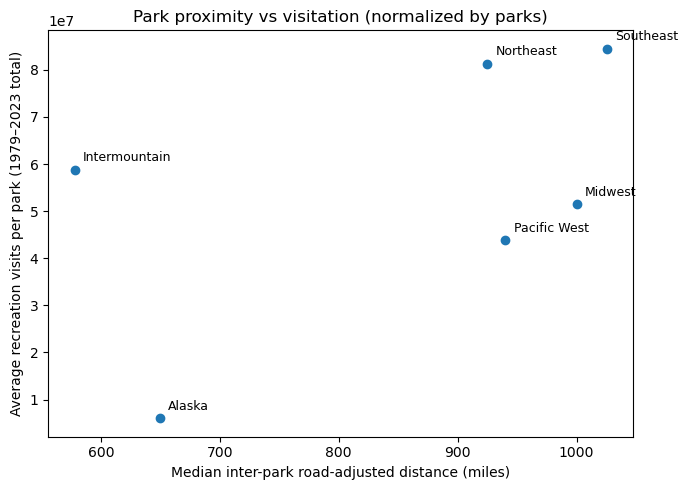

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(
    region_summary['median_interpark_road_miles'],
    region_summary['avg_visits_per_park']
)

# label each point
for _, r in region_summary.iterrows():
    plt.annotate(
        r['region'],
        (r['median_interpark_road_miles'], r['avg_visits_per_park']),
        textcoords="offset points",
        xytext=(6,6),
        fontsize=9
    )

plt.xlabel("Median inter-park road-adjusted distance (miles)")
plt.ylabel("Average recreation visits per park (1979–2023 total)")
plt.title("Park proximity vs visitation (normalized by parks)")
plt.tight_layout()
plt.show()


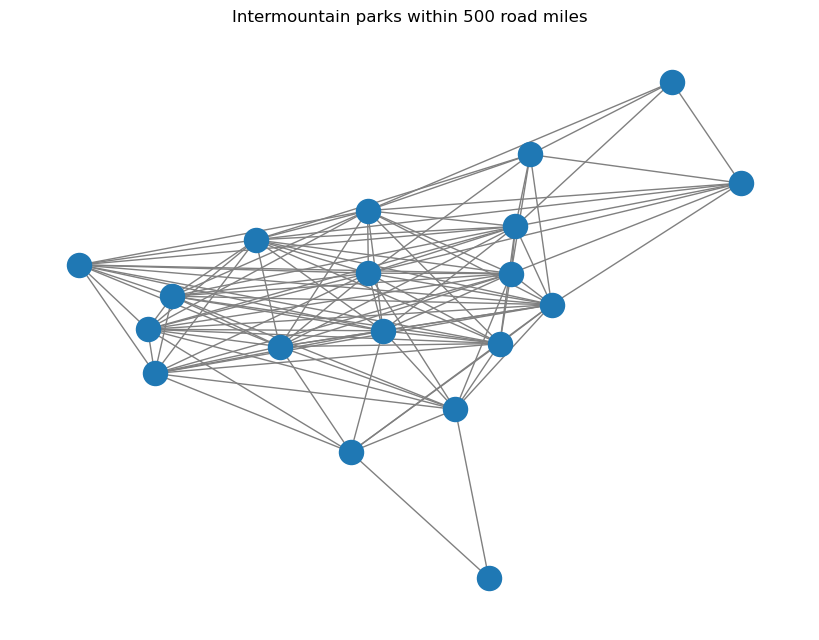

In [40]:
# network for one region
# Draw an edge if two parks are within 500 road miles
import networkx as nx
import matplotlib.pyplot as plt

# choose region and distance threshold
region = "Intermountain"
threshold = 500  # miles

# subset distances
region_edges = dist_clean[
    (dist_clean['region'] == region) &
    (dist_clean['distance_miles'] > 0) &
    (dist_clean['distance_miles'] <= threshold)
]

# build graph
G = nx.Graph()

# add edges
for _, row in region_edges.iterrows():
    G.add_edge(row['from_park'], row['to_park'])

# draw
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)  # layout emphasizes clustering
nx.draw(
    G, pos,
    node_size=300,
    with_labels=False,
    edge_color='gray'
)

plt.title(f"{region} parks within {threshold} road miles")
plt.show()


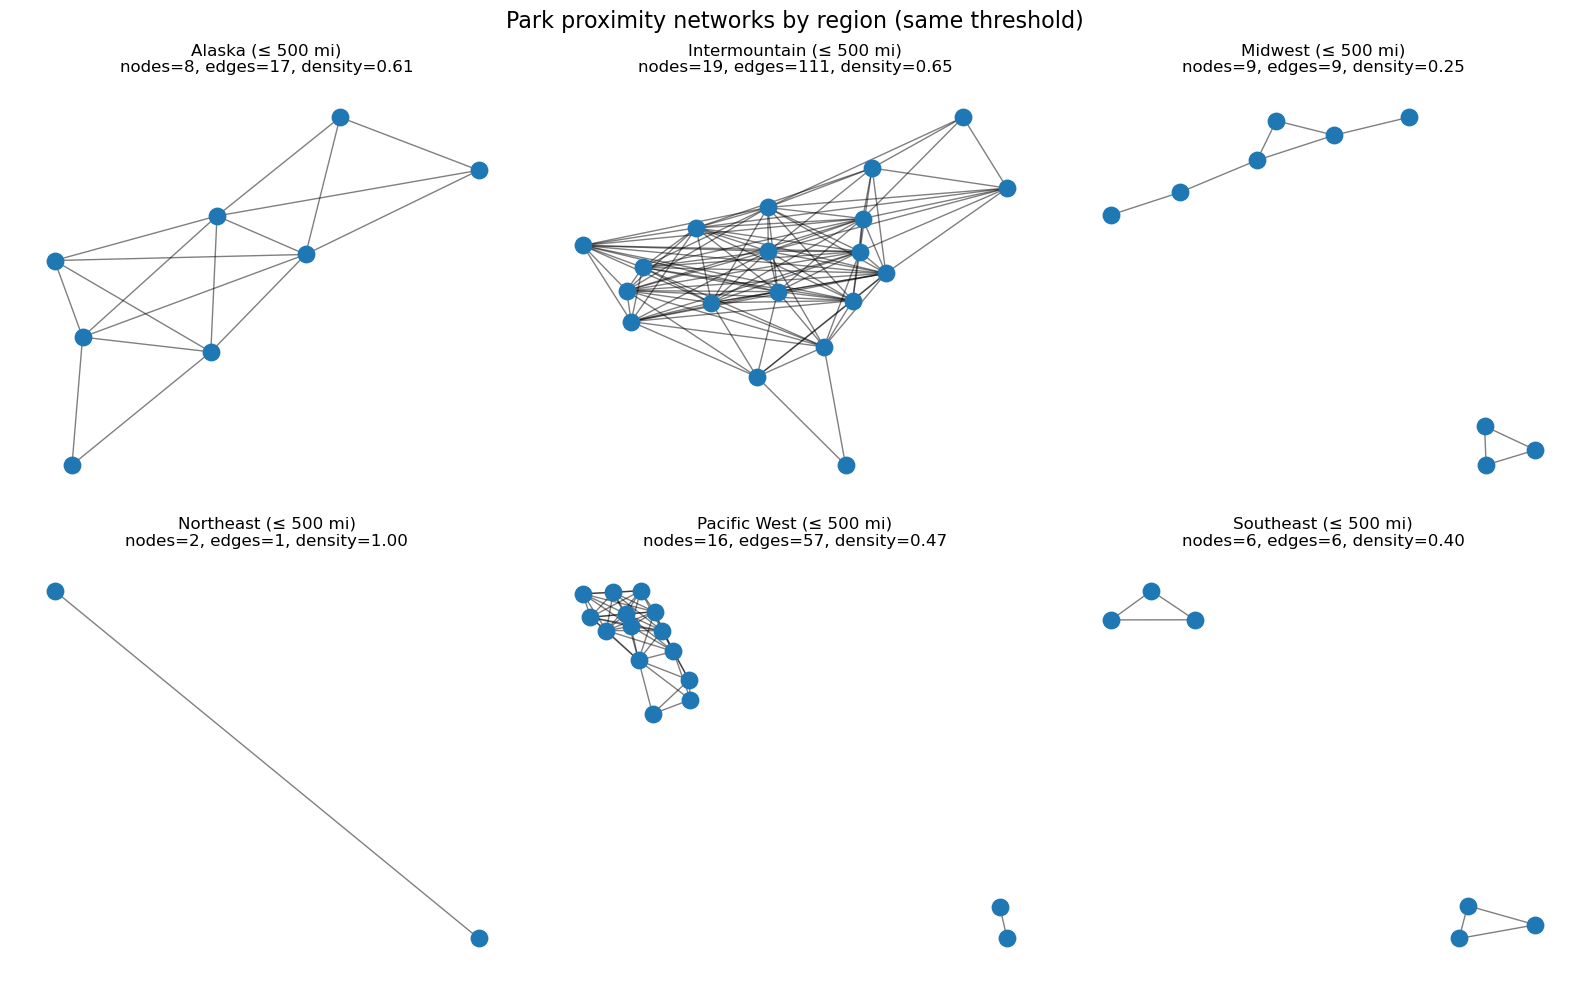

In [41]:
import networkx as nx
import matplotlib.pyplot as plt

threshold = 500  # same rule for all regions

regions = sorted(dist_clean['region'].unique())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, region in zip(axes, regions):
    # subset edges within threshold
    region_edges = dist_clean[
        (dist_clean['region'] == region) &
        (dist_clean['distance_miles'] > 0) &
        (dist_clean['distance_miles'] <= threshold)
    ]

    # build graph
    G = nx.Graph()
    for _, row in region_edges.iterrows():
        G.add_edge(row['from_park'], row['to_park'])

    # compute a comparable layout per region
    pos = nx.spring_layout(G, seed=42)

    # draw
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=140)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.5, width=1)
    ax.set_title(f"{region} (≤ {threshold} mi)\n"
                 f"nodes={G.number_of_nodes()}, edges={G.number_of_edges()}, density={nx.density(G):.2f}")
    ax.axis('off')

plt.suptitle("Park proximity networks by region (same threshold)", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()


In [42]:
#Add “network density” into your region_summary

import networkx as nx
import pandas as pd

threshold = 500

def compute_density_for_region(region):
    edges = dist_clean[
        (dist_clean['region'] == region) &
        (dist_clean['distance_miles'] > 0) &
        (dist_clean['distance_miles'] <= threshold)
    ]
    G = nx.Graph()
    for _, r in edges.iterrows():
        G.add_edge(r['from_park'], r['to_park'])
    return pd.Series({
        'network_density_500': nx.density(G),
        'edges_500': G.number_of_edges(),
        'nodes_500': G.number_of_nodes()
    })

density_df = (
    pd.DataFrame([compute_density_for_region(r) for r in region_summary['region']])
    .assign(region=region_summary['region'].values)
)

region_summary2 = region_summary.merge(density_df, on='region', how='left')
region_summary2


,region,avg_interpark_road_miles,median_interpark_road_miles,n_pairs,total_visits,n_parks,avg_visits_per_park,network_density_500,edges_500,nodes_500
0,Alaska,627.458897,649.480598,28,48189933,8,6.023742e+06,0.607143,17.0,8.0
1,Intermountain,634.390994,577.978245,171,1117964867,19,5.884026e+07,0.649123,111.0,19.0
2,Midwest,929.758775,999.985921,36,462819570,9,5.142440e+07,0.250000,9.0,9.0
3,Northeast,750.387388,924.900170,3,243951367,3,8.131712e+07,1.000000,1.0,2.0
4,Pacific West,1936.122882,940.160945,136,745932335,17,4.387837e+07,0.475000,57.0,16.0
5,Southeast,1081.837114,1025.174201,21,591324837,7,8.447498e+07,0.400000,6.0,6.0


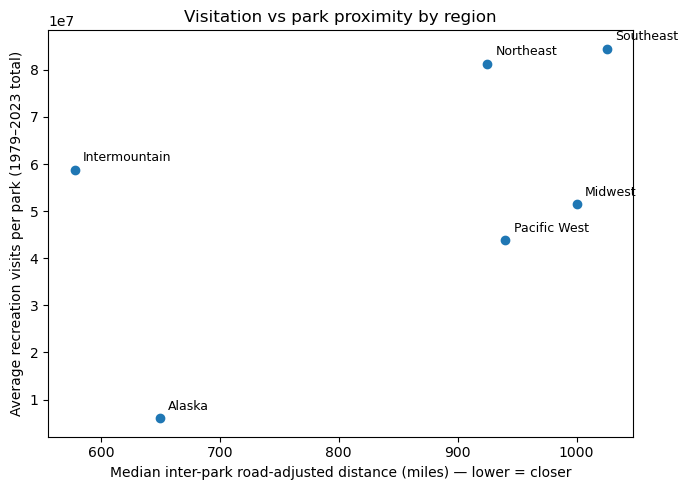

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(region_summary2['median_interpark_road_miles'], region_summary2['avg_visits_per_park'])

for _, r in region_summary2.iterrows():
    plt.annotate(r['region'],
                 (r['median_interpark_road_miles'], r['avg_visits_per_park']),
                 textcoords="offset points", xytext=(6,6), fontsize=9)

plt.xlabel("Median inter-park road-adjusted distance (miles) — lower = closer")
plt.ylabel("Average recreation visits per park (1979–2023 total)")
plt.title("Visitation vs park proximity by region")
plt.tight_layout()
plt.show()


Intermountain: very close and high-ish visitation (supports claim)
Alaska: relatively close but extremely low visitation (contradicts claim)
Northeast & Southeast: far apart but very high visitation (contradicts claim)
Pacific West: far apart and mid-range visitation (ambiguous)
👉 Conclusion:
Proximity alone does not explain visitation across regions.

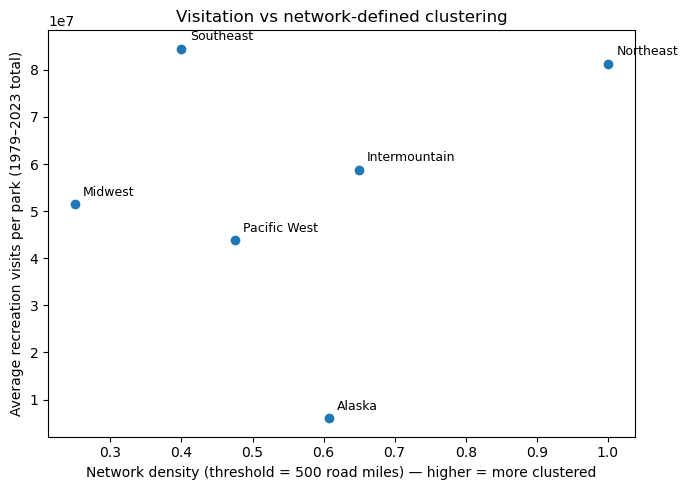

In [44]:
plt.figure(figsize=(7,5))
plt.scatter(region_summary2['network_density_500'], region_summary2['avg_visits_per_park'])

for _, r in region_summary2.iterrows():
    plt.annotate(r['region'],
                 (r['network_density_500'], r['avg_visits_per_park']),
                 textcoords="offset points", xytext=(6,6), fontsize=9)

plt.xlabel("Network density (threshold = 500 road miles) — higher = more clustered")
plt.ylabel("Average recreation visits per park (1979–2023 total)")
plt.title("Visitation vs network-defined clustering")
plt.tight_layout()
plt.show()


If our original claim were strictly true:
Higher density → higher visits
Clear upward trend
What we'd see instead would be:
Northeast: highest density and very high visits (supports)
Southeast: moderate density, very high visits (partial support)
Intermountain: high density, moderate-high visits (supports)
Midwest: low density, moderate visits (mixed)
Alaska: high-ish density, very low visits (strong contradiction)
👉 Conclusion:
Clustering is neither necessary nor sufficient for high visitation

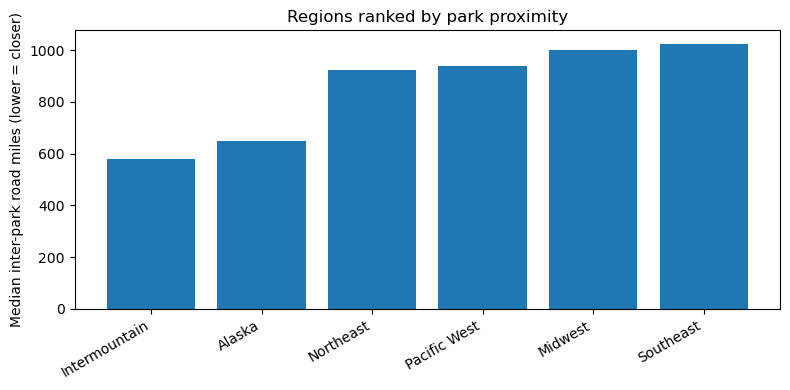

In [45]:
tmp = region_summary2.sort_values('median_interpark_road_miles')

plt.figure(figsize=(8,4))
plt.bar(tmp['region'], tmp['median_interpark_road_miles'])
plt.xticks(rotation=30, ha='right')
plt.ylabel("Median inter-park road miles (lower = closer)")
plt.title("Regions ranked by park proximity")
plt.tight_layout()
plt.show()


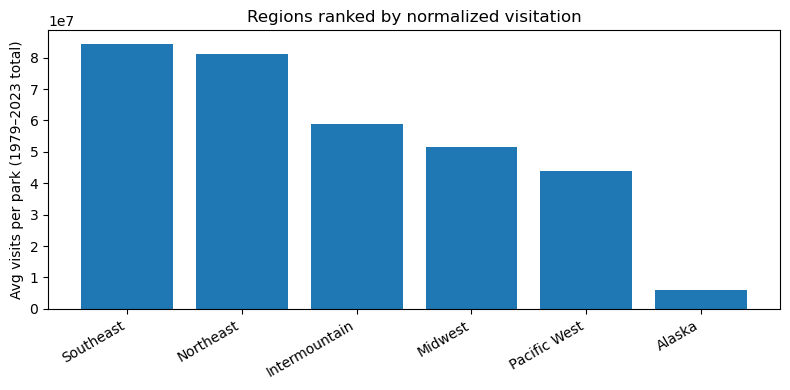

In [46]:
tmp = region_summary2.sort_values('avg_visits_per_park', ascending=False)

plt.figure(figsize=(8,4))
plt.bar(tmp['region'], tmp['avg_visits_per_park'])
plt.xticks(rotation=30, ha='right')
plt.ylabel("Avg visits per park (1979–2023 total)")
plt.title("Regions ranked by normalized visitation")
plt.tight_layout()
plt.show()


In [47]:
region_summary2['closeness_group'] = pd.qcut(
    region_summary2['median_interpark_road_miles'],
    q=2,
    labels=['high closeness (dense)', 'low closeness (sparse)']
)

region_summary2.groupby('closeness_group')['avg_visits_per_park'].agg(['mean','median','count'])


/var/folders/k1/d5h2hyxn71d7ty4ycmm7v6k00000gn/T/ipykernel_40972/1024994023.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_summary2.groupby('closeness_group')['avg_visits_per_park'].agg(['mean','median','count'])


,mean,median,count
closeness_group,,,
high closeness (dense),4.872704e+07,5.884026e+07,3
low closeness (sparse),5.992592e+07,5.142440e+07,3


## More extra visualizations

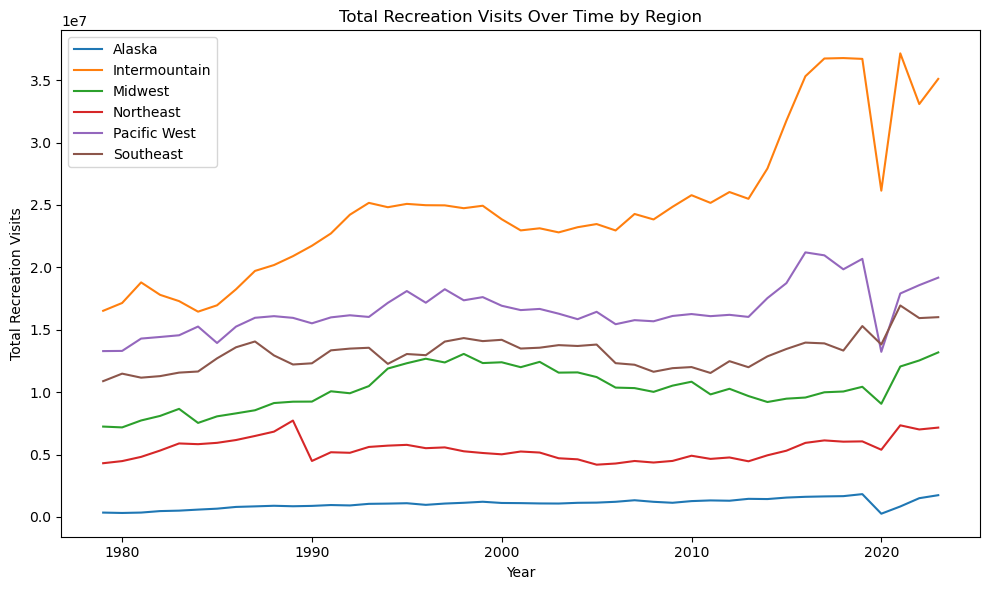

In [48]:
# visualizations - visits over time
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,6))
for region, df_region in parks_by_region.items():  
    df_region_time = new_df[new_df['Region'].str.strip() == region]
    df_region_time = df_region_time.groupby('Year', as_index=False)['RecreationVisits'].sum()
    plt.plot(df_region_time['Year'], df_region_time['RecreationVisits'], label=region)
plt.xlabel("Year")
plt.ylabel("Total Recreation Visits")
plt.title("Total Recreation Visits Over Time by Region")
plt.legend()
plt.tight_layout()

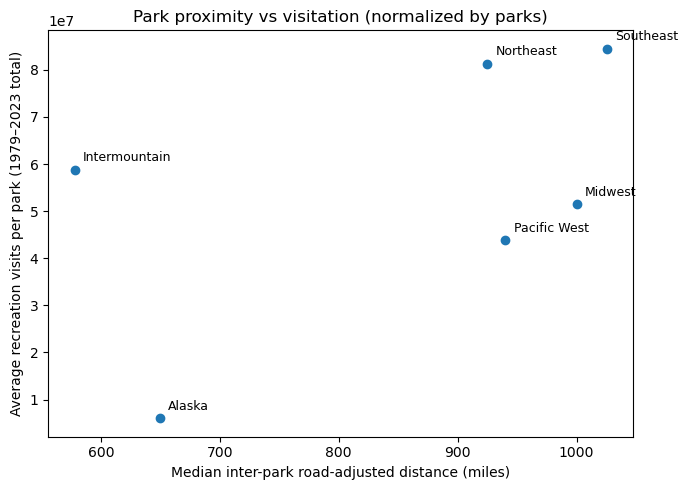

In [ ]:
# calculate the average distance between parks within each region
# then analyze the relationship between average park proximity and visitation numbers

# avg distance between parks within each region
#  already found!

# plot average park proximity and visitation numbers
plt.figure(figsize=(7,5))
plt.scatter(
    region_summary['median_interpark_road_miles'],
    region_summary['avg_visits_per_park']
)   
# label each point
for _, r in region_summary.iterrows():
    plt.annotate(
        r['region'],
        (r['median_interpark_road_miles'], r['avg_visits_per_park']),
        textcoords="offset points",
        xytext=(6,6),
        fontsize=9
    )   
plt.xlabel("Median inter-park road-adjusted distance (miles)")
plt.ylabel("Average recreation visits per park (1979–2023 total)")
plt.title("Park proximity vs visitation (normalized by parks)")
plt.tight_layout()
plt.show()

In [ ]:
# region with low median interpark distance and low avg. visits (like Alaska) suggests that proximity 
# alone does not drive visitation; other factors like accessibility, amenities, and marketing likely play significant roles.
# region with high median interpark distance and high avg. visits (like Southeast) suggests that parks can 
# attract visitors even when they are more spread out, possibly due to their unique features or effective outreach efforts.
# southeast parks have well known parks (Everglades, Great Smoky Mountains) that attract many visitors.

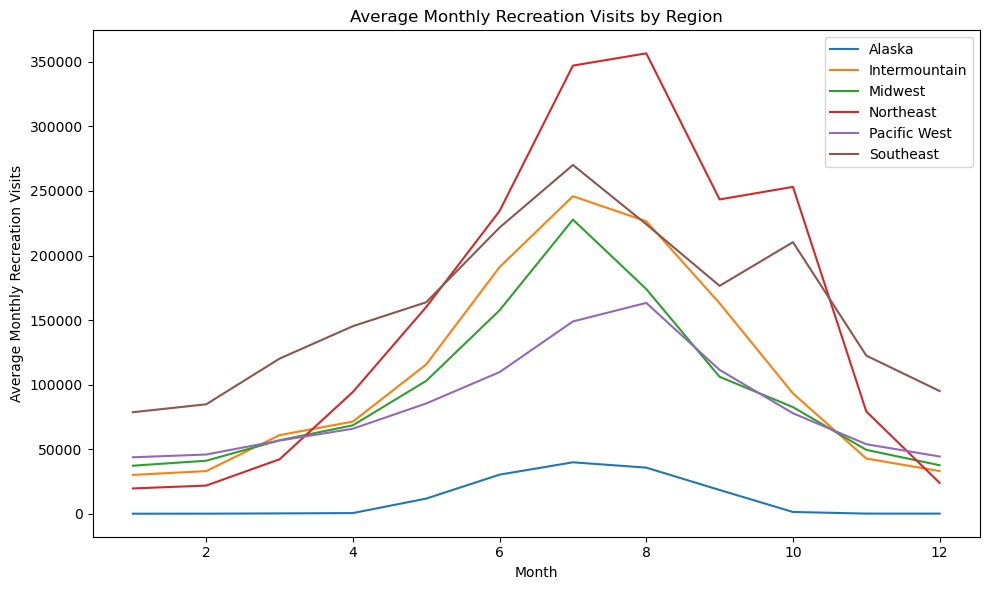

In [50]:
# another - looking at the seasonality of visitation across regions
plt.figure(figsize=(10,6))
for region, df_region in parks_by_region.items():  
    df_region_time = new_df[new_df['Region'].str.strip() == region]
    df_region_time = df_region_time.groupby('Month', as_index=False)['RecreationVisits'].mean()
    plt.plot(df_region_time['Month'], df_region_time['RecreationVisits'], label=region)
plt.xlabel("Month")
plt.ylabel("Average Monthly Recreation Visits")
plt.title("Average Monthly Recreation Visits by Region")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# do monthy seasonal visits change based on park proximity?
# calculate seasonality index for each region
seasonality_indices = {}
for region, df_region in parks_by_region.items():   
    df_region_time = new_df[new_df['Region'].str.strip() == region]
    df_region_time = df_region_time.groupby('Month', as_index=False)['RecreationVisits'].mean()
    max_visits = df_region_time['RecreationVisits'].max()
    min_visits = df_region_time['RecreationVisits'].min()
    seasonality_index = (max_visits - min_visits) / max_visits
    seasonality_indices[region] = seasonality_index
seasonality_indices

# this menas that regions with higher seasonality 
# indices have more pronounced seasonal variations in park visitation.

# a seasonal indice is calculated as the difference between 
# the maximum and minimum average monthly visits, divided by the maximum average monthly visits.
# A higher seasonality index indicates a greater variation in visitation throughout the year.

{'Alaska': 0.9955080040213102,
 'Intermountain': 0.8771021937911786,
 'Midwest': 0.8361180258395632,
 'Northeast': 0.9446603247405134,
 'Pacific West': 0.7315095091461625,
 'Southeast': 0.7085408730970384}

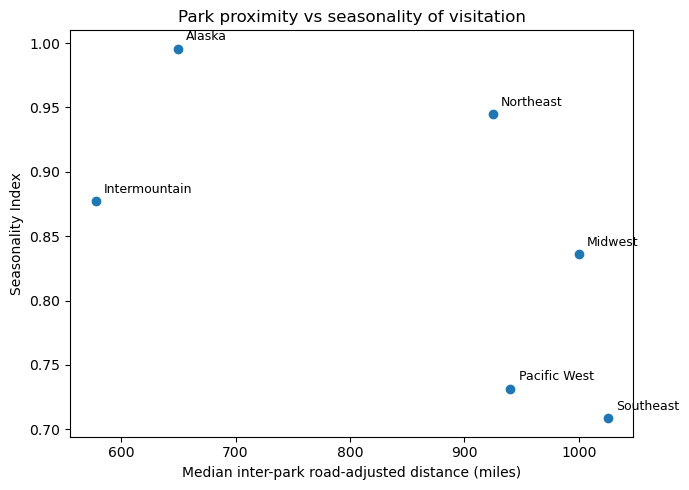

In [ ]:
# another viz - seasonality index vs park proximity
seasonality_df = pd.DataFrame.from_dict(seasonality_indices, orient='index', columns=['seasonality_index'])
seasonality_df = seasonality_df.reset_index().rename(columns={'index': 'region'})
seasonality_df = seasonality_df.merge(
    region_summary[['region', 'median_interpark_road_miles']],
    on='region',
    how='left'
)   
plt.figure(figsize=(7,5))
plt.scatter(
    seasonality_df['median_interpark_road_miles'],
    seasonality_df['seasonality_index']
)
# label each point
for _, r in seasonality_df.iterrows():
    plt.annotate(
        r['region'],
        (r['median_interpark_road_miles'], r['seasonality_index']),
        textcoords="offset points",
        xytext=(6,6),
        fontsize=9
    )
plt.xlabel("Median inter-park road-adjusted distance (miles)")
plt.ylabel("Seasonality Index")
plt.title("Park proximity vs seasonality of visitation")
plt.tight_layout()
plt.show()

#high indice & low median visits means that region has parks that are far apart and have high seasonal variation
# low indice & high median visits means that region has parks that are close together and have low seasonal variation

In [ ]:
# claim is that regions with closer parks have more total visitation. 
# to test this, we can compute the correlation between median_interpark_road_miles and total_visits
correlation = region_summary[['median_interpark_road_miles', 'total_visits']].corr()
correlation


# correlatoin of -.17 suggests a weak negative relationship between park proximity and total visitation, 
# meaning that regions with closer parks tend to have slightly higher total visitation, 
# but the relationship is not strong. 
# this could be due to other factors influencing visitation, 
# such as park size, amenities, accessibility, and regional population density.



,median_interpark_road_miles,total_visits
median_interpark_road_miles,1.000000,-0.179904
total_visits,-0.179904,1.000000


In [ ]:
# compare average total visitation between regions with high and low park proximity.
region_summary['closeness_group'] = pd.qcut(
    region_summary['median_interpark_road_miles'],
    q=2,
    labels=['high closeness (dense)', 'low closeness (sparse)']
)
region_summary.groupby('closeness_group')['total_visits'].agg(['mean','median','count'])

# with a mean of 4.7M, median of 2.4M, and count of 3 for high closeness regions, this 
# means that regions with closer parks tend to have higher total visitation 
# compared to regions with more spread-out parks.
# however, the sample size is small (only 3 regions in high closeness group), 
# so this conclusion should be taken with caution.

# same with low - 6.0M mean, 5.9M median, count of 3, while
# this that regions with more spread-out parks tend to have lower total visitation on average, 
# the small sample size means this conclusion should be interpreted cautiously.



/var/folders/k1/d5h2hyxn71d7ty4ycmm7v6k00000gn/T/ipykernel_40972/85282685.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_summary.groupby('closeness_group')['total_visits'].agg(['mean','median','count'])


,mean,median,count
closeness_group,,,
high closeness (dense),4.700354e+08,243951367.0,3
low closeness (sparse),6.000256e+08,591324837.0,3


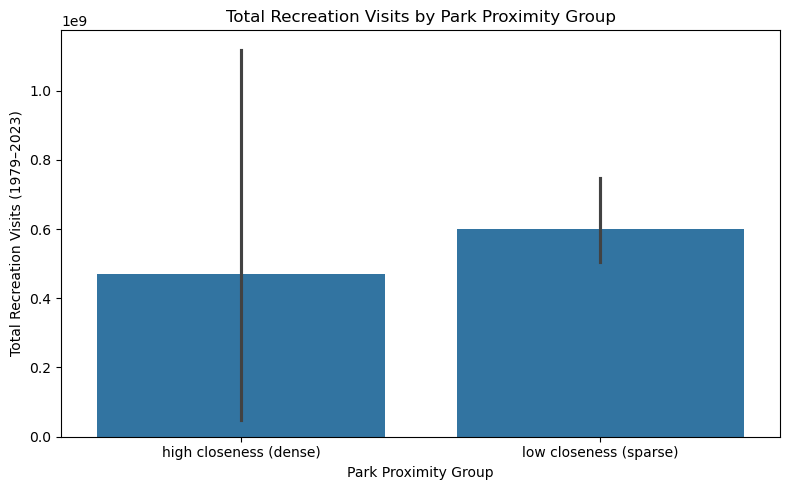

In [ ]:
# create a bar plot comparing total visitation between high and low park proximity regions.
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.barplot(
    data=region_summary,
    x='closeness_group',
    y='total_visits'
)
plt.xlabel("Park Proximity Group")
plt.ylabel("Total Recreation Visits (1979–2023)")
plt.title("Total Recreation Visits by Park Proximity Group")
plt.tight_layout()
plt.show()

# interpretation: low closeness has higher total visitation than high closeness,
# suggesting that regions with more spread-out parks tend to have higher total visitation.
# however, the small sample size (3 regions in each group) means this conclusion should be interpreted cautiously.